# Accessibility to public hospitals in Castilla-La Mancha by Travel Time

This notebook explores **healthcare accessibility in Castilla-La Mancha** by estimating the travel time from each municipality to the nearest hospital.

In this analysis:

- **Municipalities** are treated as **points** (origins).
- **Hospitals** are treated as **centers** (destinations).

Traditional spatial analyses often rely on **Euclidean distance** to measure proximity between locations. However, access to healthcare depends on **travel time through the road network**, not straight-line distance.

To capture this more realistic notion of accessibility, we compute the travel time from each municipality in Castilla-La Mancha to nearby hospitals using **routing-based travel times**.

### Methodology

The workflow is the following:

1. Use a **BallTree** with the *haversine* metric to identify the **5 geographically closest candidate hospitals** for each municipality.
2. Query the **OSRM routing API** to compute **actual travel times along the road network**.
3. Assign each municipality (point) to the hospital (center) with the **minimum travel time**.
4. Analyze accessibility by evaluating **population living beyond different travel-time thresholds**.
5. Visualize the resulting accessibility patterns on interactive maps.

## Imports

In [2]:
!pip install -r ../requirements.txt

In [3]:
import sys, os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from folium.plugins import MarkerCluster
from geopy.geocoders import Nominatim
import openrouteservice
import time

sys.path.append(os.path.abspath("../src"))

from routing import nearest_center_osrm

## Read .csv of all the municipalities in Spain

In [4]:
df_municipios = pd.read_csv(
    "../data/MUNICIPIOS.csv",
    sep=";",
    encoding="latin1"
)

df_municipios.head()

,COD_INE,ID_REL,COD_GEO,COD_PROV,PROVINCIA,NOMBRE_ACTUAL,POBLACION_MUNI,SUPERFICIE,PERIMETRO,COD_INE_CAPITAL,CAPITAL,POBLACION_CAPITAL,HOJA_MTN25_ETRS89,LONGITUD_ETRS89,LATITUD_ETRS89,ORIGENCOOR,ALTITUD,ORIGENALTITUD
0,1001000000,1010014,1010,1,Araba/Álava,Alegría-Dulantzi,2975,"1994,5872",35069,1001000101,Alegría-Dulantzi,2860,0113-3,"-2,51243731","42,83981158",Mapa,568,MDT
1,1002000000,1010029,1020,1,Araba/Álava,Amurrio,10313,"9629,68",65381,1002000201,Amurrio,9238,0086-4,"-3,00007326","43,05427776",Mapa,219,MDT
2,1003000000,1010035,1030,1,Araba/Álava,Aramaio,1409,"7308,96",42097,1003000601,Ibarra,758,0087-4,"-2,56540037","43,05119653",Mapa,333,MDT
3,1004000000,1010040,1040,1,Araba/Álava,Artziniega,1832,"2728,73",22886,1004000101,Artziniega,1697,0086-1,"-3,12791718","43,12084358",Mapa,210,MDT
4,1006000000,1010066,1060,1,Araba/Álava,Armiñón,232,"1297,27",24707,1006000101,Armiñón,113,0137-4,"-2,87183475","42,72326199",Mapa,467,MDT


##### Remove columns that are not useful and change the decimal "," in longitudes and latitudes to "."

In [5]:
df_municipios = df_municipios.drop(columns=['ID_REL', 'COD_GEO', 'POBLACION_CAPITAL', 'SUPERFICIE', 'PERIMETRO', 'COD_INE_CAPITAL', 
                                            'CAPITAL', 'HOJA_MTN25_ETRS89', 'ORIGENCOOR', 'ALTITUD', 'ORIGENALTITUD'])

df_municipios["LONGITUD_ETRS89"] = (
    df_municipios["LONGITUD_ETRS89"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

df_municipios["LATITUD_ETRS89"] = (
    df_municipios["LATITUD_ETRS89"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

df_municipios.head()

,COD_INE,COD_PROV,PROVINCIA,NOMBRE_ACTUAL,POBLACION_MUNI,LONGITUD_ETRS89,LATITUD_ETRS89
0,1001000000,1,Araba/Álava,Alegría-Dulantzi,2975,-2.512437,42.839812
1,1002000000,1,Araba/Álava,Amurrio,10313,-3.000073,43.054278
2,1003000000,1,Araba/Álava,Aramaio,1409,-2.565400,43.051197
3,1004000000,1,Araba/Álava,Artziniega,1832,-3.127917,43.120844
4,1006000000,1,Araba/Álava,Armiñón,232,-2.871835,42.723262


##### Filter municipalities belonging to provinces in Castilla-La Mancha

- `COD_PROV: 02` $\rightarrow$ Albacete
- `COD_PROV: 13` $\rightarrow$ Ciudad Real
- `COD_PROV: 16` $\rightarrow$ Cuenca
- `COD_PROV: 19` $\rightarrow$ Guadalajara
- `COD_PROV: 45` $\rightarrow$ Toledo

In [6]:
df_muni_CLM = df_municipios[df_municipios["COD_PROV"].astype(str).str.zfill(2).isin(["02", "13", "16", "19", "45"])]

len(df_muni_CLM)

919

## Read .csv with the public hospitals of CLM

In [7]:
df_hosp_CLM = pd.read_csv("../data/Hospitales_CLM.csv", sep = ";")

df_hosp_CLM.head()

,HOSPITAL,MUNICIPIO,PROVINCIA
0,Complejo Hospitalario Universitario de Albacete,Albacete,Albacete
1,Hospital General de Villarrobledo,Villarrobledo,Albacete
2,Hospital de Hellín,Hellín,Albacete
3,Hospital de Almansa,Almansa,Albacete
4,Hospital General Universitario de Ciudad Real,Ciudad Real,Ciudad Real


### Create a query for geolocating each of them

In [8]:
df_hosp_CLM["query"] = (
    df_hosp_CLM["HOSPITAL"] + ", " +
    df_hosp_CLM["MUNICIPIO"] + ", " +
    df_hosp_CLM["PROVINCIA"] + ", Spain"
)

df_hosp_CLM["query"].head()

0    Complejo Hospitalario Universitario de Albacet...
1    Hospital General de Villarrobledo, Villarroble...
2          Hospital de Hellín, Hellín, Albacete, Spain
3        Hospital de Almansa, Almansa, Albacete, Spain
4    Hospital General Universitario de Ciudad Real,...
Name: query, dtype: object

In [10]:
geolocator = Nominatim(user_agent="itv_project")

latitudes = []
longitudes = []

for q in df_hosp_CLM["query"]:

    print(q)

    try:
        location = geolocator.geocode(q)

        if location:
            latitudes.append(location.latitude)
            longitudes.append(location.longitude)
        else:
            latitudes.append(None)
            longitudes.append(None)

    except:
        latitudes.append(None)
        longitudes.append(None)

    time.sleep(0.5)

df_hosp_CLM["lat"] = latitudes
df_hosp_CLM["lon"] = longitudes

df_hosp_CLM[["HOSPITAL","lat","lon"]]

Complejo Hospitalario Universitario de Albacete, Albacete, Albacete, Spain
Hospital General de Villarrobledo, Villarrobledo, Albacete, Spain
Hospital de Hellín, Hellín, Albacete, Spain
Hospital de Almansa, Almansa, Albacete, Spain
Hospital General Universitario de Ciudad Real, Ciudad Real, Ciudad Real, Spain
Hospital General de Tomelloso, Tomelloso, Ciudad Real, Spain
Hospital General de Valdepeñas, Valdepeñas, Ciudad Real, Spain
Hospital Santa Bárbara, Puertollano, Ciudad Real, Spain
Hospital Mancha Centro, Alcázar de San Juan, Ciudad Real, Spain
Hospital Universitario de Cuenca, Cuenca, Cuenca, Spain
Hospital Universitario de Guadalajara, Guadalajara, Guadalajara, Spain
Hospital Universitario de Toledo, Toledo, Toledo, Spain
Hospital Nuestra Señora del Prado, Talavera de la Reina, Toledo, Spain


,HOSPITAL,lat,lon
0,Complejo Hospitalario Universitario de Albacete,NaN,NaN
1,Hospital General de Villarrobledo,NaN,NaN
2,Hospital de Hellín,38.504312,-1.689110
3,Hospital de Almansa,38.879489,-1.093931
4,Hospital General Universitario de Ciudad Real,NaN,NaN
5,Hospital General de Tomelloso,39.174191,-3.006050
6,Hospital General de Valdepeñas,38.771061,-3.392311
7,Hospital Santa Bárbara,38.705292,-4.112098
8,Hospital Mancha Centro,39.396536,-3.219099
9,Hospital Universitario de Cuenca,40.061095,-2.164429


### Manually fill in the coordinates if it failed

In [11]:
# Complejo Hospitalario Universitario de Albacete
df_hosp_CLM.loc[0, "lat"] = 38.98547103111702, 
df_hosp_CLM.loc[0, "lon"] = -1.8463166605322237

# Hospital General de Villarrobledo
df_hosp_CLM.loc[1, "lat"] = 39.280230233468636, 
df_hosp_CLM.loc[1, "lon"] = -2.602137989869661

# Hospital General Universitario de Ciudad Real	
df_hosp_CLM.loc[4, "lat"] = 38.97084960465921, 
df_hosp_CLM.loc[4, "lon"] = -3.930861503373964


df_hosp_CLM[["HOSPITAL","lat","lon"]]

,HOSPITAL,lat,lon
0,Complejo Hospitalario Universitario de Albacete,38.985471,-1.846317
1,Hospital General de Villarrobledo,39.280230,-2.602138
2,Hospital de Hellín,38.504312,-1.689110
3,Hospital de Almansa,38.879489,-1.093931
4,Hospital General Universitario de Ciudad Real,38.970850,-3.930862
5,Hospital General de Tomelloso,39.174191,-3.006050
6,Hospital General de Valdepeñas,38.771061,-3.392311
7,Hospital Santa Bárbara,38.705292,-4.112098
8,Hospital Mancha Centro,39.396536,-3.219099
9,Hospital Universitario de Cuenca,40.061095,-2.164429


## Obtain the nearest hospital for each municipalities, using `nearest_center_osrm`

In [12]:
df_muni_hosp_CLM,map1,map2 = nearest_center_osrm(
    df_points = df_muni_CLM, 
    df_centers = df_hosp_CLM, 
    lon_col_points = "LONGITUD_ETRS89", 
    lat_col_points = "LATITUD_ETRS89",
    lon_col_centers = "lon", 
    lat_col_centers = "lat",
    name_col_points = "NOMBRE_ACTUAL", 
    name_col_centers = "HOSPITAL", 
    batch_size = 70, 
    k = 5,
    make_map=True, 
    sleep = 0.1,
    center_icon = "hospital")


Batch 1–70 (out of 919)

Batch 71–140 (out of 919)

Batch 141–210 (out of 919)

Batch 211–280 (out of 919)

Batch 281–350 (out of 919)

Batch 351–420 (out of 919)

Batch 421–490 (out of 919)

Batch 491–560 (out of 919)

Batch 561–630 (out of 919)

Batch 631–700 (out of 919)

Batch 701–770 (out of 919)

Batch 771–840 (out of 919)

Batch 841–910 (out of 919)

Batch 911–919 (out of 919)


In [13]:
df_muni_hosp_CLM[["NOMBRE_ACTUAL","nearest_center","travel_time_min"]].head()

,NOMBRE_ACTUAL,nearest_center,travel_time_min
51,Abengibre,Complejo Hospitalario Universitario de Albacete,46.260000
52,Alatoz,Hospital de Almansa,46.348333
53,Albacete,Complejo Hospitalario Universitario de Albacete,8.251667
54,Albatana,Hospital de Hellín,27.820000
55,Alborea,Complejo Hospitalario Universitario de Albacete,48.216667


## Visualization

In [14]:
map1

In [15]:
map2

## Population vs Distance analysis

In [16]:
def population_far_from_hospital(minutes):

    # total population
    total_pop = df_muni_hosp_CLM["POBLACION_MUNI"].sum()

    # municipalities farther than the threshold
    df_near = df_muni_hosp_CLM[df_muni_hosp_CLM["travel_time_min"] <= minutes]

    # affected population
    pop_near = df_near["POBLACION_MUNI"].sum()

    # percentage
    percentage = 100 * pop_near / total_pop

    return {
        "minutes": minutes,
        "population_near": pop_near,
        "population_total": total_pop,
        "percentage": percentage
    }

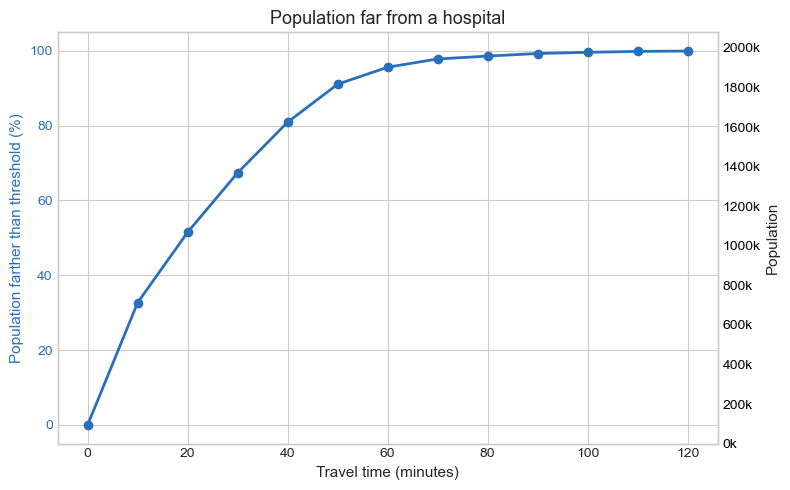

In [17]:
results = []

for m in range(0, 121, 10):
    results.append(population_far_from_hospital(m))

df_percentiles = pd.DataFrame(results)

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax1 = plt.subplots(figsize=(8,5))

# línea principal (%)
ax1.plot(
    df_percentiles["minutes"],
    df_percentiles["percentage"],
    color="#2a6fbb",
    marker="o",
    linewidth=2
)

ax1.set_xlabel("Travel time (minutes)", fontsize=11)
ax1.set_ylabel("Population farther than threshold (%)", fontsize=11, color="#2a6fbb")
ax1.tick_params(axis="y", labelcolor="#2a6fbb")

# segundo eje
ax2 = ax1.twinx()

ax2.set_ylabel("Population", fontsize=11)

# ticks cada 200k
ax2.yaxis.set_major_locator(ticker.MultipleLocator(200000))
ax2.set_ylim(0, df_percentiles["population_total"].iloc[0])

# formato de miles
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{int(x/1000)}k"))

# evitar duplicación visual de ticks
ax2.tick_params(axis="y", colors="black")
ax2.grid(False)

plt.title("Population far from a hospital", fontsize=13)

plt.tight_layout()
plt.show()

In [18]:
total_pop = sum(df_muni_CLM["POBLACION_MUNI"])

pop_more_30_min_away = population_far_from_hospital(30)
print(
    f"There are {total_pop-pop_more_30_min_away['population_near']} people living more than 30 minutes away from the nearest public hospital "
    f"({100-pop_more_30_min_away['percentage']:.2f}% of the population of CLM) \n"
)

pop_more_45_min_away = population_far_from_hospital(45)
print(
    f"There are {total_pop-pop_more_45_min_away['population_near']} people living more than 45 minutes away from the nearest public hospital "
    f"({100-pop_more_45_min_away['percentage']:.2f}% of the population of CLM) \n"
)

pop_more_60_min_away = population_far_from_hospital(60)
print(
    f"There are {total_pop-pop_more_60_min_away['population_near']} people living more than 60 minutes away from the nearest public hospital "
    f"({100-pop_more_60_min_away['percentage']:.2f}% of the population of CLM) \n"
)

pop_more_75_min_away = population_far_from_hospital(75)
print(
    f"There are {total_pop-pop_more_75_min_away['population_near']} people living more than 75 minutes away from the nearest public hospital "
    f"({100-pop_more_75_min_away['percentage']:.2f}% of the population of CLM) \n"
)

There are 678112 people living more than 30 minutes away from the nearest public hospital (32.62% of the population of CLM) 

There are 278082 people living more than 45 minutes away from the nearest public hospital (13.38% of the population of CLM) 

There are 91833 people living more than 60 minutes away from the nearest public hospital (4.42% of the population of CLM) 

There are 36912 people living more than 75 minutes away from the nearest public hospital (1.78% of the population of CLM) 

